**Tarea 2, Data Analysis and Machine Learning** \
Juan José Altamirano Paredes \
2022403951

## Librerías y descripción de variables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS
import missingno as msn

c:\Users\juanj\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Variable dictionary**

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	tiempo lineal (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc


## Carga y limpieza de datos


1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

**R:** Cargamos los datos y procedemos a limpiar según se detallan en los comentarios de las celdas.

In [ ]:
df=pd.read_csv('panel_eps.csv') #Leemos Los datos

In [3]:
borrar= ['fondoa','fondob','fondoc','fondod','fondoe','year','size'] #Borramos columnas redundantes vacías o no útiles para el análisis 
df.drop(columns=borrar,inplace=True)


In [4]:
df.describe()

,folio_n20,time,edad,hombre,edu,region,status,kids,children,situation,...,publicemp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,78017.000000,96846.000000,...,55502.000000,76203.000000,92038.000000,8.075900e+04,96846.000000,70281.000000,80408.000000,80537.000000,80537.000000,80537.000000
mean,1.253178e+11,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,0.741633,3.248797,...,0.148914,0.867669,0.410504,3.735826e+06,13.473432,131.131273,0.361096,0.213144,0.073084,0.074289
std,1.296642e+09,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,1.013718,0.608103,...,0.356006,0.338852,0.491928,9.292264e+06,10.354177,216.851544,0.480321,0.409531,0.260277,0.262242
min,1.245602e+11,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,0.000000,3.000000,...,0.000000,1.000000,0.000000,0.000000e+00,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,0.000000,3.000000,...,0.000000,1.000000,0.000000,3.960384e+05,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,1.000000,4.000000,...,0.000000,1.000000,1.000000,3.362842e+06,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,8.000000,4.000000,...,1.000000,1.000000,1.000000,2.462820e+08,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


A partir de la descripción anterior podemos notar ciertos outliers en variables como edad, expectancy, wage y assets.

In [5]:
df2=df.copy() #Creamos una copia del df original

<AxesSubplot: >

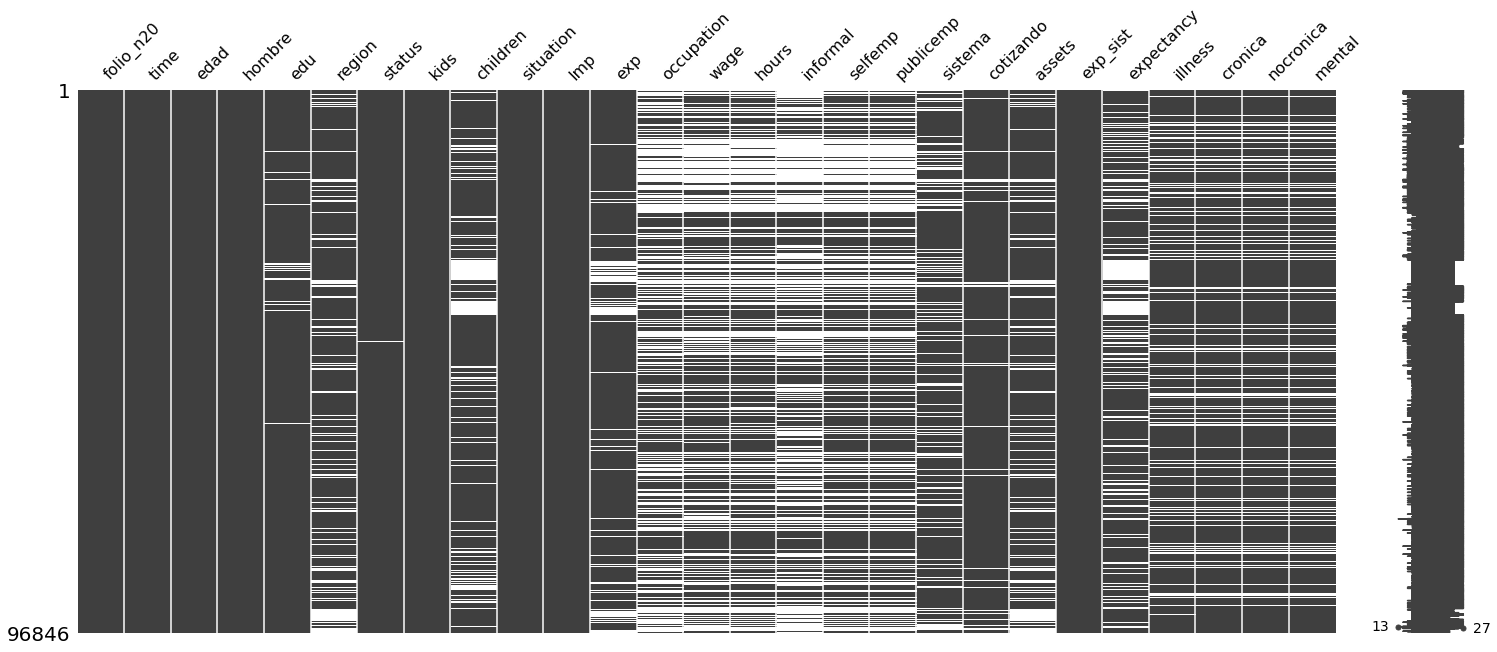

In [6]:
msn.matrix(df2) #Analizamos los vacíos en las distintas variables

In [7]:
#Asumimos que si su situación es Cesante (2) o Inactivo (4), sus horas semanales trabajadas serán 0 y su sueldo también.
es_cesante_inactivo = df2['situation'].isin([2, 4])
wage_es_nan = df2['wage'].isna()
hours_es_nan = df2['hours'].isna()

# Rellenamos con 0
df2.loc[es_cesante_inactivo & wage_es_nan, 'wage'] = 0
df2.loc[es_cesante_inactivo & hours_es_nan, 'hours'] = 0

# Quitamos outliers de horas trabajadas. (12 horas al día por 7 días es el máximo)
df2 = df2[(df2['hours'] <= 84)]


Notamos que existen outliers en Expectancy, específicamente en el periodo 4.

Imputaremos en expectancy = 999 el promedio entre la ronda siguiente y la ronda anterior del folio.
En caso de que no haya ronda siguiente o ronda anterior, se usa la más próxima.
En caso de que sea una ronda única, se elimina la observación.

In [8]:
#Ordenamos el DataFrame por individuo (folio_n20) y tiempo (time)
df2 = df2.sort_values(['folio_n20', 'time'])

# Identificamos observaciones problemáticas (time=4 y expectancy=999)
mask = (df2['time'] == 4) & (df2['expectancy'] == 999)

#Creamos columnas auxiliares con los valores anterior.
df2['prev_expectancy'] = df2.groupby('folio_n20')['expectancy'].shift(1)  # Ronda anterior
df2['next_expectancy'] = df2.groupby('folio_n20')['expectancy'].shift(-1)  # Ronda siguiente

# Imputamos según las reglas que se describieron al principio.

df2.loc[mask, 'expectancy'] = np.where(
    df2.loc[mask, 'prev_expectancy'].notna() & df2.loc[mask, 'next_expectancy'].notna(),
    (df2.loc[mask, 'prev_expectancy'] + df2.loc[mask, 'next_expectancy']) / 2,  # Promedio
    np.where(
        df2.loc[mask, 'next_expectancy'].notna(),
        df2.loc[mask, 'next_expectancy'],  # Usar ronda siguiente
        np.where(
            df2.loc[mask, 'prev_expectancy'].notna(),
            df2.loc[mask, 'prev_expectancy'],  # Usar ronda anterior
            np.nan  # Eliminar si no hay datos
        )
    )
)

# Eliminamos observaciones no imputables (sin ronda anterior ni posterior)
df2 = df2[~((df2['time'] == 4) & (df2['expectancy'].isna()))]

# Eliminamos columnas auxiliares
df2 = df2.drop(['prev_expectancy', 'next_expectancy'], axis=1)

In [9]:
df2.loc[(df2["kids"] == 0) & (df2["children"].isna()), "children"] = 0 #Si no tiene hijos y en childresn tiene NaN, rellenar con 0

### Corrección Cronica

Asumiremos que en el periodo de estudio, las enfermedades crónicas no tienen cura.
Por lo tanto, si a un individuo, en algún momento tiene una enfermedad crónica, entonces en los periodos siguientes también la tendrá.


In [10]:
df2 = df2.sort_values(['folio_n20', 'time'])

# Identificar el primer período donde cronica=1 para cada persona
primera_deteccion = df2[df2['cronica'] == 1].groupby('folio_n20')['time'].first()

# Para cada persona, actualizar todos los períodos posteriores a 1 si hubo detección
df2['cronica_2'] = df2.groupby('folio_n20')['cronica'].cummax()


In [11]:
#Si hay nan, se imputa el valor de la ronda siguiente, en caso de no haber ronda siguiente, se imputa el valor anterior.

df2 = df2.sort_values(['folio_n20', 'time'])

# Rellenamos nan con el valor del período siguiente (forward fill)
df2['cronica_ffill'] = df2.groupby('folio_n20')['cronica_2'].fillna(method='ffill')

# Rellenamos los nan restantes con el valor del período anterior (backward fill)
df2['cronica_v2'] = df2.groupby('folio_n20')['cronica_ffill'].fillna(method='bfill')

In [12]:
df2=df2[~(df2['expectancy'].isna())] #Si no cuenta con expectancy, entonces borramos la observación, pues es nuestra variable a predecir.

In [13]:
#Borramos columnas que no son de interés para el modelo y columnas auxiliares
borrar2=['region','children','occupation','informal','selfemp','publicemp','nocronica','sistema','exp',
         'cronica', 'assets',
         'cronica_2', 'cronica_ffill','mental','illness']
df2.drop(columns=borrar2,inplace=True)

df2=df2[df2['expectancy']<=120] #Solo consideramos expectativas de vida realistas.

Transformamos los sueldos a escala logarítmica, pues la magnitud de su escala es muy distinta al resto de variables.
Los resultados de sus coeficientes se interpretarán como variaciones porcentuales marginales.

In [14]:
df2['wage']=np.log(df2['wage']-df2['wage'].min()+0.1)

In [15]:
df2.dropna(inplace=True)

## Modelo Pooled OLS

In [16]:
# Seteamos los índices y transformamos en dummies las variables categóricas.
df2['tm'] = df2['time'].astype(object)
df2 = pd.get_dummies(df2,columns=['tm','status','situation','lmp'],drop_first=True)
df2 = df2.set_index(["folio_n20","time"])

c:\Users\juanj\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\algorithms.py:798: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)


Se establece como base:
- tm = 1 => Período 1
- status = 1 => Estado Civil : Casado 
- situation = 2 => Cesante
- lmp = 0 => Not Working


2. Ejecute un modelo Pooled OLS para estimar la relacion entre los años de educación y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [17]:
y=df2['expectancy']
X=df2[[
 'edu',
 'kids',
 'wage',
 'hours',
 'cotizando',
 'exp_sist',
 'cronica_v2',
 'tm_2',
 'tm_3',
 'tm_4',
 'tm_5',
 'status_2.0',
 'status_3.0',
 'status_4.0',
 'status_5.0',
 'situation_3',
 'situation_4',
# 'lmp_1',
# 'lmp_2'
]]
X=sm.add_constant(X)
model = lmp.PanelOLS(y,X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0443
Estimator:                   PanelOLS   R-squared (Between):              0.0589
No. Observations:               61561   R-squared (Within):               0.0223
Date:                Tue, May 20 2025   R-squared (Overall):              0.0443
Time:                        23:28:12   Log-likelihood                -2.308e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      167.94
Entities:                       22525   P-value                           0.0000
Avg Obs:                       2.7330   Distribution:                F(17,61543)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             167.94
                            

**R:** En base a los resultados obtenidos por el modelo, todas las variables son significativas a excepción de la cantidad de horas trabajadas semanalmente y la variable "cronica_v2" que indica si el individuo presenta alguna enfermedad crónica

Notamos que el nivel educacional presenta un efecto positivo significativo, pero muy leve sobre la expectativa de vida.

Llama la atención el efecto negativo sobre la expectativa de vida el hecho de tener hijos.

Con respecto a las categorías base, se muestra una relación positiva al pasar de un periodo a otro, es decir, a medida que se avanza entre periodos, la expectativa de vida aumenta.

Por otro lado, al tener un estado civil distinto a casado, tiende a disminuir la expectativa de vida, a excepción del estado civil 4: "Viudo", en donde la expectativa de vida, curiosamente, aumenta.



## Fixed Effects


3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [18]:
X=sm.add_constant(X)
model=lmp.PanelOLS(y,X, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0362
Estimator:                   PanelOLS   R-squared (Between):             -0.0148
No. Observations:               61561   R-squared (Within):               0.0362
Date:                Tue, May 20 2025   R-squared (Overall):              0.0076
Time:                        23:28:12   Log-likelihood                -2.031e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      86.141
Entities:                       22525   P-value                           0.0000
Avg Obs:                       2.7330   Distribution:                F(17,39019)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             70.821
                            

**R:** En el modelo de efectos fijos notamos como la gran mayoría de variables no son significativas para el modelo.
A excepción de la variable 'crónica_v2" y las dummies de cada periodo.
De esta forma, existe un impacto negativo a la expectativa de vida el hecho de padecer una enfermedad crónica y además el paso entre periodos muestra un aumento en la expectativa de vida. Este efecto podría deberse a que, a medida que el tiempo pasa, las personas ya han atravesado ciertas barreras etarias que tal vez en un inicio no creían posible, por tanto, esperan seguir viviendo más.

## Random Effects


4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [19]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4089
Estimator:              RandomEffects   R-squared (Between):              0.0533
No. Observations:               61561   R-squared (Within):               0.0280
Date:                Tue, May 20 2025   R-squared (Overall):              0.0429
Time:                        23:28:13   Log-likelihood                -2.174e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2504.5
Entities:                       22525   P-value                           0.0000
Avg Obs:                       2.7330   Distribution:                F(17,61543)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             141.05
                            

**R:** Mediante el modelo de efectos aleatorios se obtiene que todas las variables son significativas, a excepción del nivel educacional, las horas trabajadas semanalmente, la variable "cronica" y el cambio de la situación base (Cesante) a la situación 3 (Trabajando).
Se destaca la el impacto negativo que tiene el tener hijos a la expectativa de vida, similarmente a como ocurre con la experiencia en el sistema de pensiones. Por otro lado, vemos el impacto positivo sobre la expectativa de vida que tiene una variación porcentual del sueldo.


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [20]:
print(lmp.compare({"Pooled OLS": mco,
                   "Fixed Effects": fe,
                   "Random Effects": re,
                   }))

                            Model Comparison                           
                            Pooled OLS  Fixed Effects    Random Effects
-----------------------------------------------------------------------
Dep. Variable               expectancy     expectancy        expectancy
Estimator                     PanelOLS       PanelOLS     RandomEffects
No. Observations                 61561          61561             61561
Cov. Est.                   Unadjusted         Robust            Robust
R-squared                       0.0443         0.0362            0.4089
R-Squared (Within)              0.0223         0.0362            0.0280
R-Squared (Between)             0.0589        -0.0148            0.0533
R-Squared (Overall)             0.0443         0.0076            0.0429
F-statistic                     167.94         86.141            2504.5
P-value (F-stat)                0.0000         0.0000            0.0000
=====================     ============   ============   ========

**R:** Podemos notar que las principales diferencias entre los 3 modelos es la significancia de las variables para el modelo. En efectos fijos, la mayoría de variables no fueron significativas. 

Otra diferencia notoria son las magnitudes de los efectos de las variables significativas entre los modelos, por ejemplo, las dummies de la variable tiempo. Podemos notar entre los 3 modelos, que pasar del primero periodo a cualquiera de los otros 4, genera un efecto distinto a la expectativa de vida según el modelo que consideremos.
Además, notamos que contribuir al sistema de pensiones (cotizar) aumenta la expectativa de vida en todos los modelos, pero el efecto es menor en FE.

Estas diferencias se pueden explicar porque cada modelo maneja la heterogeneidad no observada de manera distinta, por ejemplo, Pooled OLS ignora de cierta manera la estructura de panel, por lo tanto no controla los efectos individuales, entonces genera un cierto sesgo. El modelo FE, elimina estos sesgos por las variables omitidas invariantes en el tiempo, pero no puede estimar los efectos de las variables invariantes, lo que puede explicar la insignificancia de tantas variables dentro del modelo.

**Para determinar qué modelo es mejor, realizamos el Test de Hausman:**



### Hausmann Test

In [21]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 463.5676006577938, df = 17, p-value = 8.764447740642826e-88


Al tener un p-value<0.05 se rechaza la Hipótesis nula que establece que el modelo adecuado es el de Random Effects.
Por lo tanto, el test sugiere utilizar el modelo de Efectos fijos por sobre el de Efectos Aleatorios, ya que los efectos no observados están correlacionados con los regresores del modelo. Se descarta el modelo Pooled OLS por ignorar la estructura de panel de los datos.

Con respecto a las variables robustas, fue posible identificar a las dummies de periodos como variables robustas a lo largo de los 3 modelos, ya que presentan un efecto positivo y significativo sobre la expectativa de vida.
Además, la variable "Cotizando" resultó ser robusta, mostrando que contribuir al sistema de pensiones también genera un leve efecto positivo y significativo a la expectativa de vida.


## Correlated Random Effects


6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [22]:
# Seleccionamos las variables que varían en el tiempo.
varian_en_t=[
 'edu',
 'kids',
 'wage',
 'hours',
 'cotizando',
 'exp_sist',
 'cronica_v2',
]

# Calculamos su media por cada folio
Xm = df2.groupby(by = 'folio_n20')[varian_en_t].transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]
Xc = pd.merge(df2,Xm, left_index=True, right_index=True) #Mezclamos el df original con las medias de las variables.



In [23]:
y=Xc['expectancy']
X=Xc[[ 'edu',
 'kids',
 'wage',
 'hours',
 'cotizando',
 'exp_sist',
 'cronica_v2',
 'tm_2',
 'tm_3',
 'tm_4',
 'tm_5',
 'status_2.0',
 'status_3.0',
 'status_4.0',
 'status_5.0',
 'situation_3',
 'situation_4',
 'medu',
 'mkids',
 'mwage',
 'mhours',
 'mcotizando',
 'mexp_sist',
 'mcronica_v2'
 ]]
X=sm.add_constant(X)

model=lmp.RandomEffects(y,X)
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.4109
Estimator:              RandomEffects   R-squared (Between):              0.0579
No. Observations:               61561   R-squared (Within):               0.0306
Date:                Tue, May 20 2025   R-squared (Overall):              0.0462
Time:                        23:28:14   Log-likelihood                -2.173e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1788.7
Entities:                       22525   P-value                           0.0000
Avg Obs:                       2.7330   Distribution:                F(24,61536)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             106.08
                            

**R:** Notamos como gran parte de las variables originales y las variables añadidas son significativas. No obstante, llaman la atención resultados como la insignificancia del efecto intra y entre individuos de las horas trabajadas semanalmente y del nivel educacional. Es decir, no hay cambios significativos en la expectativa de vida de un mismo individuo si aumenta sus años de educación, ni tampoco hay efectos significativos en expectativas de vida de gente que en promedio tiene más años de estudio. Análogamente para la cantidad de horas trabajadas semanalmente.

Otros resultados relevantes son que las enfermedades crónicas reducen expectancy en aproximadamente 0.41 años, pero que los individuos con mayor "historial de enfermedades crónicas" presentan mayor expectativa de vida (paradoja interesante...).

También destaca que personas con hijos en promedio tienen menor expectativa de vida. Para pensar señores!

Por último, si bien este modelo mezcla lo mejor de dos mundos, siendo una buena herramienta para modelar el componente no observado, podemos notar que no se capturó tan bien dichos componentes, ya que variables como
medu, mwage, mhours, mcotizando no resultaron significativas. 


7. Usando el modelo CRE, prediga la distribucion del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?


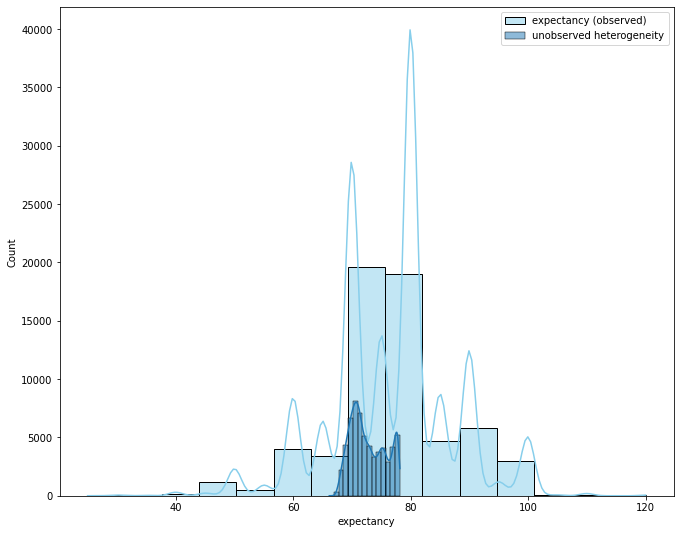

In [24]:
Xpred = X
Xpred['edu']=0
Xpred['kids']=0
Xpred['wage']=0
Xpred['hours']=0
Xpred['cotizando']=0
Xpred['exp_sist']=0
Xpred['cronica_v2']=0
Xpred['tm_2']=0
Xpred['tm_3']=0
Xpred['tm_4']=0
Xpred['tm_5']=0
Xpred['status_2.0']=0
Xpred['status_3.0']=0
Xpred['status_4.0']=0
Xpred['status_5.0']=0
Xpred['situation_3']=0
Xpred['situation_4']=0
yhat = cre.predict(Xpred)

plt.figure(figsize=(11,9))
sns.histplot(data=y, color="skyblue", label="expectancy (observed)", kde=True, 
             bins=15
             )
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True, 
             bins=15
             )

plt.legend() 
plt.show()

**R:** Gráficamente podemos notar como la heterogenidad no observada de la predicción está concentrada en torno a un rango de valores, lo que no indica mayores niveles de dispersión. Si bien se acerca a una distribución normal, podemos ver que cercano al extremo derecho de la distribución formada por la parte no observada existe otro peak, el cual se asemeja al peak en las expectativas de vida observada. Podemos ver también que ambas curvas están bien centradas, por lo que los componentes no observados no tienden a desviar mucho la predicción, es decir no tienden a sobrestimar ni subestimar.

8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

In [25]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 61561             61561             61561
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0362            0.4089            0.4109
R-Squared (Within)              0.0362            0.0280            0.0306
R-Squared (Between)            -0.0148            0.0533            0.0579
R-Squared (Overall)             0.0076            0.0429            0.0462
F-statistic                     86.141            2504.5            1788.7
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

**R:** En este caso, es preferible utilizar el método CRE, pues explica de manera más extendida la variabilidad de los resultados obtenidos, además consideran la heterogeneidad no observada.

En general, podemos inferir que en algunas variables regresoras existe una correlación significativa con factores no medidos, esto se sustenta en la significancia de varaibles como "mkids" y "mexp_sist".

También, se se infiere que parte del efecto en la expectativa de vida de avanzar de un periodo a otro se debe a heterogeneidad no observada, pues los coeficientes de tm_2-tm_5 disminuye en al pasar de un modelo RE a CRE.

Por lo tanto, CRE permite corregir ciertos sesgos que ocurren en otros modelos debidos a supuestos que no necesariamente se cumplen con los datos del estudio.